# Barotropic / baroclinic instability of a zonal jet in a channel

A shallow-water experiment (`OSSWEM`) on a $\beta$-plane. The domain is a zonal channel:
**periodic in $x$**, with **solid walls north and south**. A balanced eastward jet is held
against instability by a localized sponge, while the interior of the channel is free to
evolve.

`[NP]` **The meridional boundary condition is a switch.** `Y_PERIODIC` in the configuration
cell selects how the north/south walls are made:

| `Y_PERIODIC` | walls | how |
|---|---|---|
| `False` (default) | free-slip solid walls at $y=0$ and $y=L_y$ | the model's own boundary condition (`SSWEM(..., y_periodic=False)`) |
| `True` | emulated | the domain is doubly periodic, so the walls are faked by drying out the first and last row ($D=0$), as this notebook did before the model had walls |

The `False` path is the better one: no dry rows means no $h\to 0$, so the potential
vorticity $q=(f+\zeta)/h$ does not spike at the boundary and no wall masking is needed in
the diagnostics. `True` reproduces the old behaviour for comparison.

`[2L]` The notebook runs **either a 1-layer or a 2-layer model**. Everything below is
written $n_k$-generically and the layer count is set by a single preset in the
configuration cell, where $n_k = $ `len(g)`. Every diagnostic cell exposes a `K_LAYER`
switch and **defaults to `K_LAYER = 0`, the top layer**; set it to 1 and re-run that cell
to see the deep layer.

## The problem

A zonal jet $\bar{u}(y)$ that is sharp enough develops a sign change in the meridional
gradient of background potential vorticity. By the **Rayleigh–Kuo / Charney–Stern**
criterion this is a *necessary* condition for barotropic instability. The jet here
satisfies it, so a small perturbation grows into meanders and eddies that flux momentum
and stir PV — the classic route by which a jet sheds eddies. The localized sponge keeps
re-supplying the unstable jet, so the channel reaches a statistically steady turbulent
state rather than mixing the jet away.

With a single layer the instability is purely *barotropic* (drawing on the horizontal
shear of the mean flow); there is no vertical-shear energy source. With two layers and a
`jet_amp_k = [1.0, 0.0]` preset the jet also has vertical shear, so the **Phillips**
(baroclinic) route opens as well — the criterion cell tests both.

## Configuration

Set `CONFIG` in the configuration cell. The presets differ only in the numbers below;
the code path is identical.

| Preset | $n_k$ | $g$ [m s$^{-2}$] | $H_o$ [m] | jet | seed |
|---|---|---|---|---|---|
| `1layer_1jet` | 1 | `[0.08]` | `[800]` | one jet at $y/L_y=1/2$, 1 m s$^{-1}$ | `[+20]` |
| `1layer_2jet` | 1 | `[0.08]` | `[800]` | two jets at $y/L_y=2/5,\,3/5$ | `[+20]` |
| `2layer_baroclinic` | 2 | `[0.08, 0.06]` | `[400, 400]` | upper layer 1 m s$^{-1}$, deep layer at rest | `[+20, -20]` |

Shared across presets:

| Quantity | Value | Notes |
|---|---|---|
| Domain | $2500$ km $\times\ L_y$ | $\Delta x = \Delta y = 10$ km at `nj = 180` |
| Coriolis $f_0$, $\beta$ | $10^{-4}$ s$^{-1}$, $3\times10^{-11}$ m$^{-1}$s$^{-1}$ | set `beta = 0` for an $f$-plane |
| Bottom drag $\epsilon$ | $2.5\times10^{-5}$ m s$^{-1}$ | at $n_k>1$ this acts on the **bottom layer only** |
| Lateral viscosity $\nu_h$ | $200$ m$^2$ s$^{-1}$ | $\nu_v = 0$: layers couple through pressure only |

- **Balanced state:** built $n_k$-generically from per-layer geostrophy on the Montgomery
  potential $M_k=\sum_{l\le k} g_l\eta_l$, i.e. $f\,u_k = -\partial_y M_k$, so
  $\partial_y\eta_k = -(f/g_k)(u_k - u_{k-1})$. At $n_k=1$ this is the single-layer
  $\eta$; at $n_k=2$ with $u_1=0$ it is the Margules interface of a deep layer at rest.
- **Sponge (forcing):** restores $u\to$ jet, $v\to 0$, $h\to$ balanced at rate
  $10^{-5}$ s$^{-1}$ over the westernmost `Lw` plus the outer `yb` near each wall.
  The restoring is applied with a backward-Euler step (unconditionally stable). The rest
  of the domain is unforced.
- **Seed:** smooth Gaussian bumps in $h$, one amplitude per layer (`perturb_k`).
  `[+20, +20]` seeds a barotropic (free-surface) eddy; `[+20, -20]` a baroclinic one
  (pure interface displacement, flat free surface).

## Notebook outline

1. **Configuration** — boundary condition, resolution, run length, sponge widths, preset.
2. **Setup** — build the model, jet, balanced state, sponge, and seed; plot the configuration.
3. **Instability criteria** — Rayleigh–Kuo / Charney–Stern, and Phillips at $n_k>1$.
4. **Run** — integrate forward, sampling snapshots.
5. **Snapshot** — final $\eta$, eddy field $\eta'$, absolute vorticity, and PV.
6. **Time series** — surface-height and velocity extrema, and kinetic energy vs. time.
7. **Animation** — evolution of potential vorticity.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from OSSWEM import SSWEM

# Configuration

## Meridional boundary condition `[NP]`

`Y_PERIODIC` picks how the channel walls are made — see the table at the top of the
notebook. It is passed straight to the model constructor as `y_periodic=`, and it is the
*only* thing that needs changing: the dry-row fallback, the near-wall diagnostic masking
and the plot cropping all follow from it automatically.

## Layers and jet

This notebook supports running either a 1-layer or a 2-layer model. Pick a preset with
`CONFIG` below; `nk = len(g)` is the only layer switch, and every cell downstream is
written to work for any layer count.

| key | meaning |
|---|---|
| `g` | reduced gravity per interface [m s$^{-2}$]; `len(g) == nk` — **sets the layer count** |
| `Ho` | nominal layer thickness per layer [m]; `len(Ho) == nk` |
| `nj` | meridional resolution ($n_i = L_x/\Delta x$ is set in the setup cell) |
| `run_params` | `[dt, steps/segment, segments]` |
| `Lw`, `yb` | western sponge width / N–S near-wall sponge band [m] |
| `jet_centers` | jet centre(s) as a fraction of $L_y$, one entry per jet |
| `jet_hw` | jet half-width [m] |
| `jet_scale` | scalar multiplying the summed meridional bump profile |
| `jet_amp_k` | per-layer peak jet speed [m s$^{-1}$], `len == nk`. `[1,1]` barotropic, `[1,0]` baroclinic |
| `perturb_k` | per-layer $h$-perturbation [m], `len == nk`. `[+20,+20]` barotropic seed, `[+20,-20]` baroclinic seed |

In [2]:
#   False -> free-slip solid walls at y = 0 and y = Ly, handled by the model itself.
#            No dry rows, so h stays O(Ho) everywhere and q = (f+zeta)/h is well behaved
#            right up to the wall.
#   True  -> the model stays doubly periodic and the channel walls are emulated the old
#            way, by drying out the first and last row (D = 0). Kept for comparison.
Y_PERIODIC = False

# time configuration: time-step [s] / steps per sample / number of samples
run_params = [200., 1, 10]
# run_params = [200., 500, 25]     # shorter run, still shows the instability

# sponge widths: western sponge Lw, N/S near-wall band yb [m]
Lw = 300e3
yb = 250e3

# number of rows
nj = 180
# nj = 60                          # coarser / much faster

# df/dy [m-1 s-1]  (the beta-plane arrests the large-scale meridional mode)
beta = 3.0e-11
# beta = 0                         # f-plane

In [3]:
CONFIG = '1layer_1jet'          # '1layer_1jet' | '1layer_2jet' | '2layer_baroclinic'
PRESETS = {
  # ---- single layer, single jet (the original barotropic-instability setup) --------
  '1layer_1jet': dict(
      g=[0.08], Ho=[800.], nj=nj, run_params=run_params, Lw=Lw, yb=yb,
      jet_centers=[1/2], jet_hw=60e3, jet_scale=1.0, jet_amp_k=[1.0],
      perturb_k=[+20.]),
  # ---- single layer, double jet ---------------------------------------------------
  '1layer_2jet': dict(
      g=[0.08], Ho=[800.], nj=nj, run_params=run_params, Lw=Lw, yb=yb,
      jet_centers=[2/5, 3/5], jet_hw=60e3, jet_scale=1.4, jet_amp_k=[1.0],
      perturb_k=[+20.]),
  # ---- two layers, baroclinic jet (upper layer flows, deep layer at rest) ----------
  # g'/g0 = 0.75
  '2layer_baroclinic': dict(
      g=[0.08, 0.06], Ho=[400., 400.], nj=nj, run_params=run_params, Lw=Lw, yb=yb,
      jet_centers=[1/2], jet_hw=60e3, jet_scale=1.0, jet_amp_k=[1.0, 0.0],
      perturb_k=[+20., -20.]),
}
CFG = PRESETS[CONFIG]
print(f"[CFG] {CONFIG}:  nk = {len(CFG['g'])}   g = {CFG['g']}   Ho = {CFG['Ho']}   "
      f"run_params = {CFG['run_params']}")
print(f"[NP]  y_periodic = {Y_PERIODIC}   -> "
      + ("doubly periodic; N/S walls emulated with dry rows (D = 0)" if Y_PERIODIC
         else "free-slip solid walls at y = 0 and y = Ly"))

[CFG] 1layer_1jet:  nk = 1   g = [0.08]   Ho = [800.0]   run_params = [200.0, 1, 10]
[NP]  y_periodic = False   -> free-slip solid walls at y = 0 and y = Ly


mesh: ni = 250  nj = 180
Grid: dx = 10000.0 [m]  dy = 10000.0 [m]
cg = 8.0 [m s-1]
Ld = 80000.0 [m]
Scales: Ls=epsilon/D/beta = 1041.6666666666667 [m]
Scales: Lx/Ld = 31.25
Res: Ld/dx = 8.0
Res: Ls/dx = 0.10416666666666667
[2L] min balanced layer thickness:  h0 = 752.6 m   <- keep well away from 0 (outcropping)
[2L] cg  = 8.000 m/s   Courant dt*cg/dx  = 0.160
[2L] exact modes: c0 = 8.000 m/s (Courant 0.160)


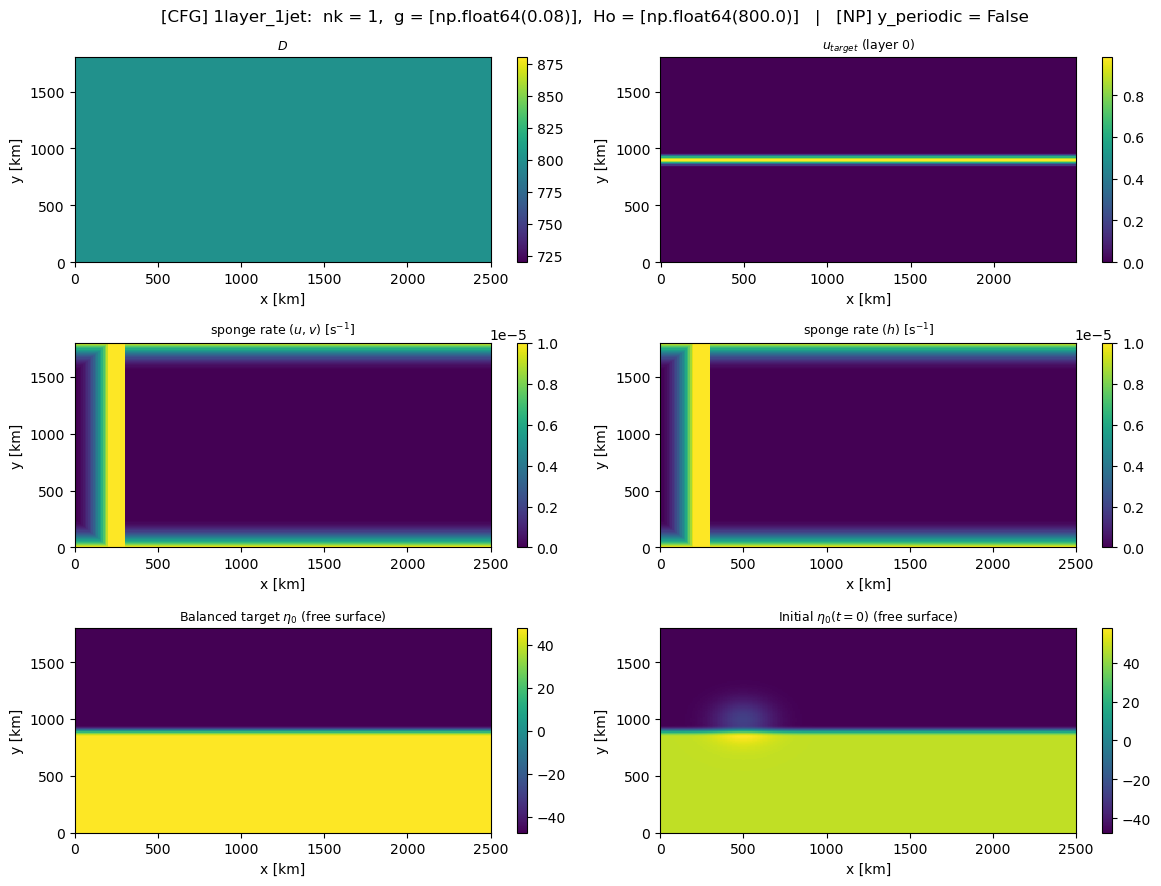

In [ ]:
nj         = int(CFG['nj'])                # [CFG] resolution / run length come from the preset
run_params = list(CFG['run_params'])       # [CFG]

# Resolution and domain
dx = 10.e3
Lx = 2500.e3

M = SSWEM(int(Lx / dx),
          CFG['g'],   # [2L] list -> nk = len(g); [0.08] reproduces the old scalar 1-layer case
          CFG['Ho'],  # [2L] nominal layer thickness per layer [m]
          Lx,      # Domain width [m]
          1e-4,    # Coriolis [s-1]
          beta,    # df/dy [m-1 s-1]
          2.5e-5,  # Bottom drag rate [m s-1]   # [2L] at nk>1 this acts on the BOTTOM layer only
          2e2,     # Lateral viscosity [m2 s-1]
          nj=nj,   # Rectangular channel
          y_periodic=Y_PERIODIC,   # [NP] False -> the model's own free-slip N/S walls
          )
nk = M.nk

if Y_PERIODIC:
    M.D[0, :]  = 0                         # dry rows N/S -> zonal channel walls
    M.D[-1, :] = 0
    M.resting_state()                      # re-derive h from the modified D
    jcut = slice(2, -2)                    # [NP] crop the dry rows from the q / vorticity plots
else:
    jcut = slice(1, None)                  # [NP] q()/abs_omega() still j-wrap in their helpers,
                                           # [NP] so row 0 of those DIAGNOSTICS is not meaningful
                                           # [NP] (the prognostic fields u, v, h are fine there).

# ------------------------- [CFG] meridional jet profile ----------------------------------
# Sum of cubic bumps (one per entry of jet_centers), scaled per layer by jet_amp_k. This one
# expression covers the single jet, the double jet, and the 2-layer baroclinic jet
# (amplitude 0 in the deep layer) with no branching.
yc      = M.yu / M.Ly                                  # non-dim y at u-points
hw      = CFG['jet_hw'] / M.Ly                         # half-width of each jet
bump    = lambda c: SSWEM._cubint(yc, c - hw, c) - SSWEM._cubint(yc, c, c + hw)
profile = CFG['jet_scale'] * sum(bump(c) for c in CFG['jet_centers'])
amp_k   = np.asarray(CFG['jet_amp_k'], dtype=float)                                   # [2L]
assert amp_k.size == nk, f"[CFG] jet_amp_k needs {nk} entries, got {amp_k.size}"       # [2L]
M.u_target = np.empty_like(M.u)
for k in range(nk):                                                                   # [2L]
    M.u_target[k, :] = amp_k[k] * profile              # peak speed per layer [m/s]

# ------------- [2L] nk-generic balanced state (per-layer geostrophic balance) -------------
# Montgomery potential M_k = sum_{l<=k} g_l eta_l and layer-k geostrophy f u_k = -dM_k/dy give
#     deta_k/dy = -(f/g_k) * (u_k - u_{k-1}),        u_{-1} := 0
# nk=1 reduces to the single-layer eta (deta0/dy = -f u0/g0); nk=2 with u_1 = 0 gives the
# Margules interface deta1/dy = +f u0/g', i.e. a deep layer at rest under a tilted free surface.
f_h   = M.fo + M.beta * M.yh1                  # f(y) at row centres
eta_d = np.zeros((nk, M.nj))                   # interface displacements from rest [m]
u_km1 = np.zeros(M.nj)                         # u of the layer above (0 above layer 0)
for k in range(nk):
    u_k      = M.u_target[k].mean(axis=1)      # U_k(y)
    e        = -(1.0 / M.g[k]) * np.cumsum(f_h * (u_k - u_km1)) * M.dy
    eta_d[k] = e - e.mean()                    # zero domain mean -> mean layer volumes stay at Ho
    u_km1    = u_k

# Absolute interface heights: interface k rests at z = -sum_{l<k} Ho[l]; the bottom is z = -D.
eta_abs = np.empty((nk + 1, M.nj, M.ni))
for k in range(nk):
    eta_abs[k] = -M.Ho[:k].sum() + eta_d[k][:, None]
eta_abs[nk] = -M.D
hbal = np.maximum(eta_abs[:-1] - eta_abs[1:], 0.0)     # (nk, nj, ni) balanced thicknesses
for k in range(nk):                                    # wall-row clamps: flat target against the wall
    hbal[k, 0, :]  = hbal[k, 1, 1]
    hbal[k, -1, :] = hbal[k, -2, 1]
print("[2L] min balanced layer thickness:  "
      + "   ".join(f"h{k} = {hbal[k].min():.1f} m" for k in range(nk))
      + "   <- keep well away from 0 (outcropping)")

# ============================= Sponge Layer Setup ==============================================

# Sponges restoring u->jet, v->0, h->balanced: a western sponge over the westernmost Lw,
# plus N/S near-wall sponges over the outer yb.
# Local forcing only; the rest of the domain is free to evolve.
def ramp(x, x0, Lx, p=2):             return np.clip((x - x0)/(Lx - x0), 0, 1)**p
def ramp2(x, x0, Lx, factor=1.5):     return np.clip(factor*(x - x0)/(Lx - x0), 0, 1)**2
rate_h, rate_uv = 1.e-5, 1.e-5                       # restoring rates [s-1]
Lw_uv = Lw_h    = float(CFG['Lw'])                   # [CFG] western sponge width [m]
yb              = float(CFG['yb'])                   # [CFG] N/S near-wall band [m]

assert 2 * yb < M.Ly, (f"the two near-wall sponges overlap: 2*yb = {2*yb/1e3:.0f} km "
                       f">= Ly = {M.Ly/1e3:.0f} km -- lower yb or raise nj")
assert Lw_uv < M.Lx, "the western sponge fills the domain"

# The western sponge rises W->E over [0, Lw] and is masked to 0 beyond Lw, so it drops
# discontinuously to 0 at x = Lw. The N/S bands ramp up over the outer yb at each wall.
M.u_relax  = rate_uv * np.maximum( np.maximum( ramp2(M.xu, 0., Lw_uv) * (M.xu < Lw_uv), ramp(M.yu, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yu, M.Ly - yb, M.Ly) )
M.v_relax  = rate_uv * np.maximum( np.maximum( ramp2(M.xv, 0., Lw_uv) * (M.xv < Lw_uv), ramp(M.yv, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yv, M.Ly - yb, M.Ly) )
M.h_relax  = rate_h  * np.maximum( np.maximum( ramp2(M.xh, 0., Lw_h ) * (M.xh < Lw_h ), ramp(M.yh, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yh, M.Ly - yb, M.Ly) )
M.h_target = hbal.copy()                           # [2L] per-layer (nk, nj, ni) target; u_target/v_target already set (jet / 0)

#====================================== END ======================================================

# Balanced initial state everywhere + a small smooth perturbation to seed eddies
M.u[:] = M.u_target.copy()                         # [2L] all layers (deep layers start at their target)
M.h[:] = hbal.copy()                               # [2L]
perturb_k = np.asarray(CFG['perturb_k'], dtype=float)                                      # [2L]
assert perturb_k.size == nk, f"[CFG] perturb_k needs {nk} entries, got {perturb_k.size}"    # [2L]
for k, mag in enumerate(perturb_k):                # [2L] same-sign pair -> barotropic seed,
    if mag != 0.0:                                 # [2L] opposite-sign pair -> baroclinic seed
        M.perturb_h(mag, 0.05 * M.Lx, 0.2 * M.Lx, 0.55 * M.Ly, k=k)

ic = (M.u.copy(), M.v.copy(), M.h.copy(), M.time, M.iter)   # initial condition, for the diagnostics

# --------------- [2L] CFL check (valid for any layer count) ---------------
dt_cfg = run_params[0]
print(f"cg  = {M.cg:.3f} m/s   Courant dt*cg/dx  = {dt_cfg*M.cg/M.dx:.3f}")
if M.cg1 is not None:                                       # only defined at nk == 2
    print(f"cg1 = {M.cg1:.3f} m/s   Courant dt*cg1/dx = {dt_cfg*M.cg1/M.dx:.3f}")
Bmat    = np.array([[M.Ho[k] * M.g[:min(k, l) + 1].sum() for l in range(nk)] for k in range(nk)])
c_modes = np.sqrt(np.sort(np.linalg.eigvals(Bmat).real)[::-1])
print('exact modes: ' + '   '.join(
    f'c{i} = {c:.3f} m/s (Courant {dt_cfg*c/M.dx:.3f})' for i, c in enumerate(c_modes)))

# Setup diagnostics
panels  = [(r'$D$', M.D, M.xh1)]
panels += [(rf'$u_{{target}}$ (layer {k})', M.u_target[k], M.xq1) for k in range(nk)]
panels += [(r'sponge rate ($u,v$) [s$^{-1}$]', M.u_relax[0], M.xh1),
           (r'sponge rate ($h$) [s$^{-1}$]',   M.h_relax[0], M.xh1)]
for k in range(nk):
    lbl = 'free surface' if k == 0 else 'interface'
    panels += [(rf'Balanced target $\eta_{k}$ ({lbl})', M.h_target[k:].sum(axis=0) - M.D + M.Ho[:k].sum(), M.xh1),
               (rf'Initial $\eta_{k}(t=0)$ ({lbl})',    M.eta(k=k) + M.Ho[:k].sum(),                       M.xh1)]

nrow = int(np.ceil(len(panels) / 2))
fig, ax = plt.subplots(nrow, 2, figsize=(12, 3 * nrow), squeeze=False)
for a, (title, fld, xax) in zip(ax.ravel(), panels):
    cs = a.pcolormesh(xax/1e3, M.yh1/1e3, fld); fig.colorbar(cs, ax=a)
    a.set_title(title, fontsize=9); a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
for a in ax.ravel()[len(panels):]:
    a.axis('off')                                  # no trailing panel
fig.suptitle(f'[CFG] {CONFIG}:  nk = {nk},  g = {list(M.g)},  Ho = {list(M.Ho)}   |   '
             f'[NP] y_periodic = {Y_PERIODIC}')
fig.tight_layout()

Rayleigh-Kuo (beta - U_yy) changes sign in interior: True


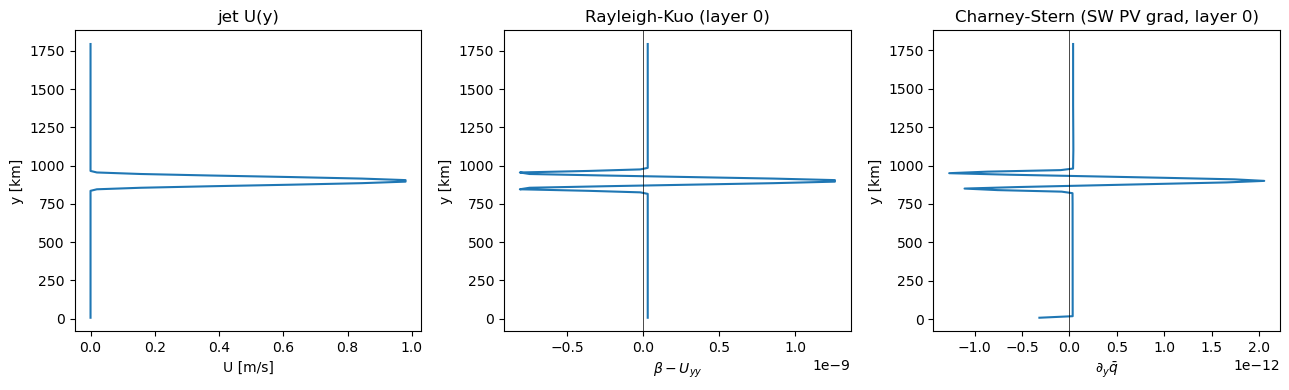

In [5]:
# Barotropic-instability criterion (Rayleigh-Kuo / Charney-Stern): a NECESSARY
# condition for instability is that the background potential-vorticity gradient
# changes sign in the interior. Evaluated on the initial balanced jet.
# See https://en.wikipedia.org/wiki/Rayleigh%E2%80%93Kuo_criterion
K_LAYER = 0                                        # [2L] layer these panels describe; 0 = top layer

U   = M.u[K_LAYER].mean(axis=1)                    # U(y) in the selected layer
Uyy = np.gradient(np.gradient(U, M.yh1), M.yh1)
RK  = M.beta - Uyy                                 # Rayleigh-Kuo (non-divergent barotropic)
dqdy = np.gradient(M.q(k=K_LAYER).mean(axis=1), M.yq1)   # Charney-Stern: d/dy of zonal-mean SW PV
# [NP] With dry rows, h -> 0 makes q = (f+zeta)/h spike and swamp the interior, so the wall
# [NP] rows have to be masked. With real walls h stays O(Ho) and only row 0 needs dropping,
# [NP] because q() itself still j-wraps in its shift helpers (a diagnostic-only detail).
dqdy[:3 if Y_PERIODIC else 1] = np.nan
if Y_PERIODIC:
    dqdy[-2:] = np.nan

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(U, M.yh1/1e3, label=f'layer {K_LAYER}')
for k in range(nk):                                                                   # [2L]
    if k != K_LAYER:
        ax[0].plot(M.u[k].mean(axis=1), M.yh1/1e3, '--', label=f'layer {k}')          # [2L]
if nk > 1: ax[0].legend(fontsize=8)                                                   # [2L]
ax[0].set_xlabel('U [m/s]'); ax[0].set_ylabel('y [km]'); ax[0].set_title('jet U(y)')
ax[1].plot(RK, M.yh1/1e3);   ax[1].axvline(0, color='k', lw=0.5); ax[1].set_xlabel(r'$\beta - U_{yy}$'); ax[1].set_ylabel('y [km]'); ax[1].set_title(f'Rayleigh-Kuo (layer {K_LAYER})')
ax[2].plot(dqdy, M.yq1/1e3); ax[2].axvline(0, color='k', lw=0.5); ax[2].set_xlabel(r'$\partial_y \bar{q}$'); ax[2].set_ylabel('y [km]'); ax[2].set_title(f'Charney-Stern (SW PV grad, layer {K_LAYER})')
fig.tight_layout()
# With the near-wall spike masked, the interior sign change in the SW PV gradient is
# visible in the Charney-Stern panel; the Rayleigh-Kuo panel is the cleaner read.

jj = (M.yh1/M.Ly > 0.12) & (M.yh1/M.Ly < 0.88)     # interior (skip the sponge bands)
print('Rayleigh-Kuo (beta - U_yy) changes sign in interior:', bool((RK[jj].min() < 0) and (RK[jj].max() > 0)))

# Phillips baroclinic-instability criterion: for two layers it requires the per-layer
# zonal-mean PV gradient to change sign BETWEEN layers.
if nk > 1:
    dqdy_k = []
    for kk in range(nk):
        gk = np.gradient(M.q(k=kk).mean(axis=1), M.yq1)
        gk[:3 if Y_PERIODIC else 1] = np.nan       # [NP] same near-wall mask as above
        if Y_PERIODIC: gk[-2:] = np.nan
        dqdy_k.append(gk)

    fig2, ax2 = plt.subplots(1, 1, figsize=(5, 4))
    for kk in range(nk):
        ax2.plot(dqdy_k[kk], M.yq1/1e3, label=f'layer {kk}')
    ax2.axvline(0, color='k', lw=0.5); ax2.legend(fontsize=8)
    ax2.set_xlabel(r'$\partial_y \bar{q}_k$'); ax2.set_ylabel('y [km]')
    ax2.set_title('Phillips: per-layer zonal-mean PV gradient')
    fig2.tight_layout()

    jj2   = (M.yq1/M.Ly > 0.12) & (M.yq1/M.Ly < 0.88)
    _prod = dqdy_k[0][jj2] * dqdy_k[-1][jj2]       # top vs bottom layer
    print('Phillips: opposite-signed interior PV gradients between layers:',
          bool(np.nanmin(_prod) < 0))

In [6]:
# Run the model (control run)
%time u, v, h, time = M.run(*run_params);   # dt, steps/segment, segments

if not Y_PERIODIC:
    # The south wall sits on the v-row j=0, which the model pins to zero every step.
    # This one is exact -- anything but 0.0 means the wall is not being enforced.
    print(f'[NP] south-wall normal velocity: max|v[:,0,:]| = {np.abs(v[:,:,0,:]).max():.3e} m/s  (must be exactly 0)')
    # With walls, x is the only periodic direction, so the DYNAMICS conserve mass exactly.
    # The drift below is the h sponge adding/removing mass, not a leak through the walls:
    # re-run with M.h_relax = 0 and it goes to 0.000e+00.
    m0, m1 = ic[2].sum(), h[-1].sum()
    print(f'[NP] sum(h) {m0:.6e} -> {m1:.6e}   drift = {abs(m1-m0)/m0:.2e}   '
          f'(sponge-driven; zero when h_relax = 0)')

numba threads = 16
CFL: dt*f = 0.03074
CFL: dt*cg/dx = 0.16
CFL: dt*nu_h/dx^2 = 0.0004
CFL*: dt*epsilon/h_bot = 6.25e-06
CFL*: dt*nu_v/h_min^2 = 0.0
CFL*: dt*h_relax = 0.002
CFL*: dt*u_relax = 0.002
CFL*: dt*v_relax = 0.002
nsteps = 10
Time: Trun * fo = 0.2
Time: Trun * ( cg / L ) = 0.0064
Running...
...done
CPU times: total: 32.7 s
Wall time: 33.6 s
[NP] south-wall normal velocity: max|v[:,0,:]| = 0.000e+00 m/s  (must be exactly 0)
[NP] sum(h) 3.601963e+07 -> 3.601961e+07   drift = 5.64e-07   (sponge-driven; zero when h_relax = 0)


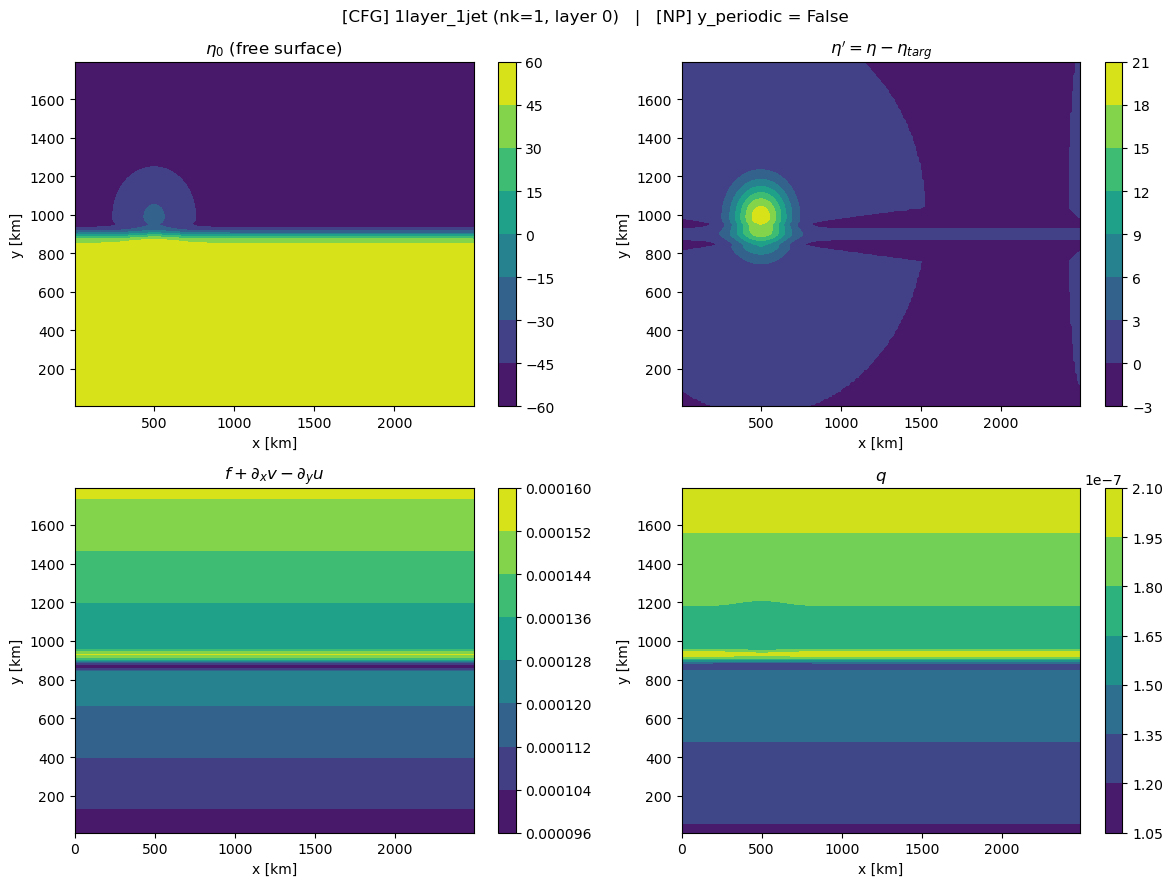

In [7]:
# Snapshot
K_LAYER = 0                                        # [2L] layer to plot; 0 = top layer
lbl = 'free surface' if K_LAYER == 0 else 'interface'
eta_k      = M.eta(k=K_LAYER) + M.Ho[:K_LAYER].sum()                                  # [2L]
eta_targ_k = M.h_target[K_LAYER:].sum(axis=0) - M.D + M.Ho[:K_LAYER].sum()            # [2L]

fig, axs = plt.subplots(2, 2, figsize=(12, 9))
cs = axs[0,0].contourf( M.xh1/1e3, M.yh1/1e3, eta_k ); fig.colorbar(cs, ax=axs[0,0]); axs[0,0].set_title(rf"$\eta_{K_LAYER}$ ({lbl})");
cs = axs[0,1].contourf( M.xh1/1e3, M.yh1/1e3, eta_k - eta_targ_k ); fig.colorbar(cs, ax=axs[0,1]); axs[0,1].set_title(r"$\eta' = \eta - \eta_{targ}$");
cs = axs[1,0].contourf( M.xq1/1e3, M.yq1[jcut]/1e3, M.abs_omega(k=K_LAYER)[jcut,:] ); fig.colorbar(cs, ax=axs[1,0]); axs[1,0].set_title(r'$f + \partial_x v - \partial_y u$');
cs = axs[1,1].contourf( M.xq1/1e3, M.yq1[jcut]/1e3, M.q(h=h[-1], u=u[-1], v=v[-1], k=K_LAYER)[jcut,:] ); fig.colorbar(cs, ax=axs[1,1]); axs[1,1].set_title(r'$q$');
for a in axs.ravel():
    a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
fig.suptitle(f'[CFG] {CONFIG} (nk={nk}, layer {K_LAYER})   |   [NP] y_periodic = {Y_PERIODIC}')
fig.tight_layout();

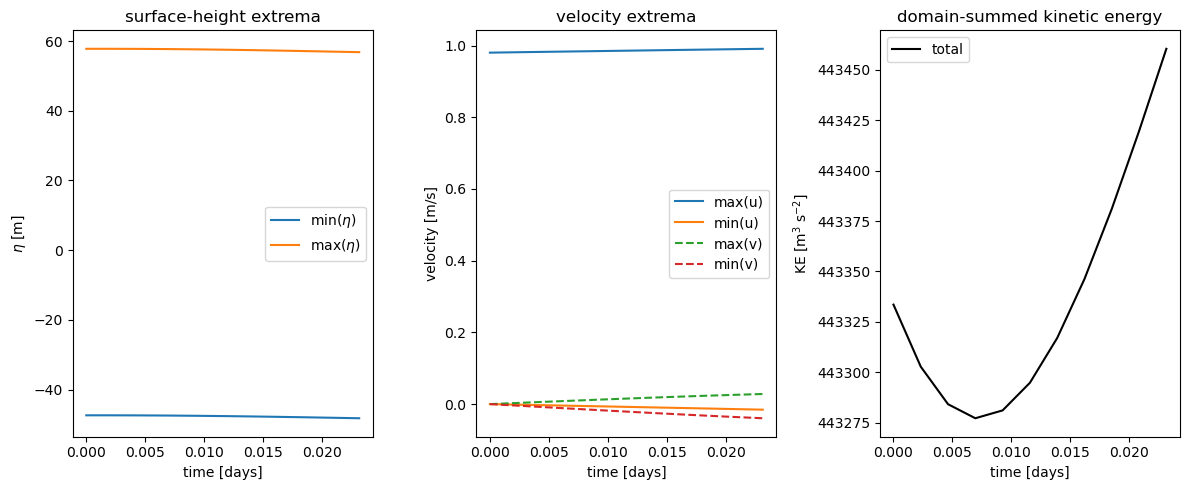

In [8]:
# Plot time series (summed over all layers)
fig,ax = plt.subplots(1,3,figsize=(12,5))
ax[0].plot( time/86400, (h - M.D).min(axis=(1,2,3)), label=r'min($\eta$)' )
ax[0].plot( time/86400, (h - M.D).max(axis=(1,2,3)), label=r'max($\eta$)' )
ax[0].set_xlabel('time [days]'); ax[0].set_ylabel(r'$\eta$ [m]'); ax[0].set_title('surface-height extrema'); ax[0].legend();
ax[1].plot( time/86400, u.max(axis=(1,2,3)), label='max(u)' )
ax[1].plot( time/86400, u.min(axis=(1,2,3)), label='min(u)' )
ax[1].plot( time/86400, v.max(axis=(1,2,3)), '--', label='max(v)' )
ax[1].plot( time/86400, v.min(axis=(1,2,3)), '--', label='min(v)' )
ax[1].set_xlabel('time [days]'); ax[1].set_ylabel('velocity [m/s]'); ax[1].set_title('velocity extrema'); ax[1].legend();
KE = M.KE(h=h, u=u, v=v)
ax[2].plot( time/86400, KE.sum(axis=(1,2,3)), 'k', label='total' )
if nk > 1:                                                                            # [2L]
    for k in range(nk):
        ax[2].plot( time/86400, KE[:,k].sum(axis=(1,2)), '--', label=f'layer {k}' )
ax[2].set_xlabel('time [days]'); ax[2].set_ylabel(r'KE [m$^3$ s$^{-2}$]'); ax[2].set_title('domain-summed kinetic energy'); ax[2].legend();
fig.tight_layout();

In [9]:
# Animate
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

K_LAYER = 0                                        

fig, ax = plt.subplots()
# Compute PV for all time levels
pv = np.array([M.q(h=h[n], u=u[n], v=v[n], k=K_LAYER)[jcut, :] for n in range(len(time))])
ykm = M.yq1[jcut] / 1e3

# Use consistent color limits across frames
vmin, vmax = pv.min(), pv.max()
cf = ax.contourf(M.xq1/1e3, ykm, pv[-1], levels=20, vmin=vmin, vmax=vmax)
cb = fig.colorbar(cf)
ax.axvline(Lw_uv/1e3, color='k', ls=':', lw=1)    # sponge edge: the model is free east of it
ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')
title = ax.set_title(f'$q$ at t = {time[0]/86400:.2f} days')

def update(n):
    ax.clear()
    ax.contourf(M.xq1/1e3, ykm, pv[n], levels=20, vmin=vmin, vmax=vmax)
    ax.axvline(Lw_uv/1e3, color='k', ls=':', lw=1)    # sponge edge (ax.clear wipes it)
    ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')  # restore labels (ax.clear wipes them)
    ax.set_title(f'$q$ (layer {K_LAYER}) at t = {time[n]/86400:.2f} days')

anim = FuncAnimation(fig, update, frames=len(time), interval=100)
plt.close(fig)
HTML(anim.to_jshtml())